In [1]:
import pandas as pd 


In [2]:
import matplotlib.pyplot as plt 

In [3]:
import numpy as np 
import seaborn as sns

In [5]:
df=pd.read_csv("C:\\Users\\tript\\OneDrive\\Desktop\\internsip\\02_nav_history.csv")

In [6]:
df.head(11)

,amfi_code,date,nav
0,119551,2022-01-03,54.3856
1,119551,2022-01-04,54.3474
2,119551,2022-01-05,54.6869
3,119551,2022-01-06,55.4550
4,119551,2022-01-07,55.3692
5,119551,2022-01-10,55.2835
6,119551,2022-01-11,56.0878
7,119551,2022-01-12,56.4978
8,119551,2022-01-13,56.2934
9,119551,2022-01-14,56.5926


In [7]:
df

,amfi_code,date,nav
0,119551,2022-01-03,54.3856
1,119551,2022-01-04,54.3474
2,119551,2022-01-05,54.6869
3,119551,2022-01-06,55.4550
4,119551,2022-01-07,55.3692
...,...,...,...
45995,149324,2026-05-25,292.4810
45996,149324,2026-05-26,291.2707
45997,149324,2026-05-27,288.8007
45998,149324,2026-05-28,280.6873


In [8]:
df.isnull().sum()

amfi_code    0
date         0
nav          0
dtype: int64

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46000 entries, 0 to 45999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   amfi_code  46000 non-null  int64  
 1   date       46000 non-null  object 
 2   nav        46000 non-null  float64
dtypes: float64(1), int64(1), object(1)
memory usage: 1.1+ MB


In [11]:
df.describe()

,amfi_code,nav
count,46000.000000,46000.000000
mean,120247.000000,269.570265
std,14352.317221,577.187060
min,100016.000000,26.136600
25%,118632.750000,69.170425
50%,119551.500000,122.732150
75%,120842.250000,260.338675
max,149324.000000,4268.549700


In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df["date"] = pd.to_datetime(df["date"])

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46000 entries, 0 to 45999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   amfi_code  46000 non-null  int64         
 1   date       46000 non-null  datetime64[ns]
 2   nav        46000 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(1)
memory usage: 1.1 MB


In [15]:
df = df.sort_values(
    by=["amfi_code","date"]
)

In [16]:
(df["nav"] <= 0).sum()

np.int64(0)

In [17]:
df["nav"] = df.groupby("amfi_code")["nav"].ffill()

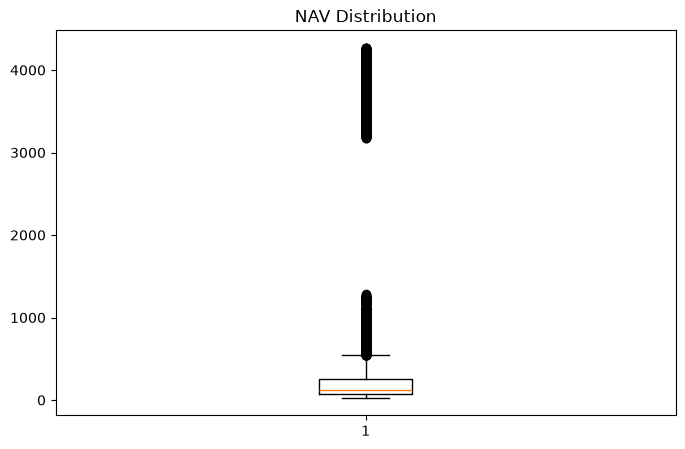

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.boxplot(df["nav"])
plt.title("NAV Distribution")
plt.show()

In [20]:
Q1 = df["nav"].quantile(0.25)
Q3 = df["nav"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df["nav"] < lower) | (df["nav"] > upper)]

print("Number of outliers:", len(outliers))
outliers.head()

Number of outliers: 3494


,amfi_code,date,nav
6061,100016,2023-03-14,547.4632
6063,100016,2023-03-16,557.8920
6064,100016,2023-03-17,559.0670
6065,100016,2023-03-20,558.0108
6066,100016,2023-03-21,554.1991


In [21]:
outliers.sort_values("nav", ascending=False).head(10)

,amfi_code,date,nav
27599,120844,2026-05-29,4268.5497
27598,120844,2026-05-28,4266.9021
27597,120844,2026-05-27,4264.9256
27596,120844,2026-05-26,4262.3302
27594,120844,2026-05-22,4260.3220
27593,120844,2026-05-21,4259.2780
27595,120844,2026-05-25,4259.2727
27592,120844,2026-05-20,4258.9179
27591,120844,2026-05-19,4256.2918
27588,120844,2026-05-14,4255.9472


In [22]:
### Outlier Analysis

print("Outliers were detected using the IQR method and visualized using a boxplot.A total of 3,494 statistical outliers were identified.")
print("Further investigation showed that these values belong to valid mutual funds (e.g., AMFI Code 120844) and follow a consistent day-to-day NAV progression.")
print("Since these represent genuine financial observations rather than data entry errors, no outliers were removed.")

Outliers were detected using the IQR method and visualized using a boxplot.A total of 3,494 statistical outliers were identified.
Further investigation showed that these values belong to valid mutual funds (e.g., AMFI Code 120844) and follow a consistent day-to-day NAV progression.
Since these represent genuine financial observations rather than data entry errors, no outliers were removed.


In [23]:
print("Negative NAV values:", (df["nav"] < 0).sum())
print("Zero NAV values:", (df["nav"] == 0).sum())

Negative NAV values: 0
Zero NAV values: 0


In [25]:
df.to_csv("...02_nav_history_clean.csv...", index=False)